In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score , mean_absolute_error

In [12]:
df = pd.read_csv("ev_car_India_dataset.csv")
print(df)

       Brand               Model  Price  Range   Power  Battery
0     Maruti       SuzukieVitara  15.99  440.0  142.00    49.00
1       Tata             PunchEV   9.69  275.0   87.00    30.00
2   Mahindra               XEV9e  21.90  542.0  228.00    59.00
3   Mahindra                 BE6  18.90  557.0  228.00    59.00
4         MG           WindsorEV  14.00  332.0  134.00    38.00
5         MG             CometEV   7.50  230.0   41.42    17.30
6         MG           Cyberster  75.00  580.0  503.00    77.00
7       Tata             NexonEV  12.49  275.0  127.00    30.00
8       Tata           HarrierEV  21.49  538.0  235.00    65.00
9       Tata             TiagoEV   7.99  250.0   60.34    19.20
10   Hyundai       CretaElectric  18.02  473.0  133.00    42.00
11     Vayve         MobilityEva   3.25  175.0   16.00    12.60
12       Kia                 EV6  65.97  663.0  321.00    84.00
13        MG                ZSEV  17.99  461.0  174.33    50.30
14   VinFast                 VF7  21.89 

In [13]:
df.head()

,Brand,Model,Price,Range,Power,Battery
0,Maruti,SuzukieVitara,15.99,440.0,142.0,49.0
1,Tata,PunchEV,9.69,275.0,87.0,30.0
2,Mahindra,XEV9e,21.90,542.0,228.0,59.0
3,Mahindra,BE6,18.90,557.0,228.0,59.0
4,MG,WindsorEV,14.00,332.0,134.0,38.0


In [17]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26 entries, 0 to 25
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Brand    26 non-null     object 
 1   Model    26 non-null     object 
 2   Price    26 non-null     float64
 3   Range    26 non-null     float64
 4   Power    26 non-null     float64
 5   Battery  26 non-null     float64
dtypes: float64(4), object(2)
memory usage: 1.3+ KB


,Price,Range,Power,Battery
count,26.000000,26.000000,26.000000,26.000000
mean,28.770000,443.423077,191.531154,52.677692
std,21.781663,121.837654,102.742266,20.775912
min,3.250000,175.000000,16.000000,12.600000
25%,15.615000,388.750000,136.000000,39.000000
50%,18.460000,468.000000,174.330000,54.650000
75%,40.747500,536.250000,233.250000,66.050000
max,75.000000,663.000000,503.000000,90.000000


In [18]:
df.shape

(26, 6)

In [19]:
df = df.dropna(subset=["Range","Price"])
df[["Range","Price"]].isnull().sum()

,0
Range,0
Price,0


In [43]:
X = df[["Range"]]
y = df[["Price"]]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [44]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [45]:
print("Slope",model.coef_[0])
print("Intercept",model.intercept_)

Slope [0.14140953]
Intercept [-34.39612071]


In [53]:
y_pred=model.predict(X_test)

In [58]:
comparison_df = pd.DataFrame({
    "Actual Price": y_test.values.ravel(),
    "Predicted Price": y_pred.ravel()
})

comparison_df.head(10)

,Actual Price,Predicted Price
0,21.49,41.682205
1,17.29,31.783538
2,15.99,27.824071
3,72.50,33.904681
4,3.25,-9.649453
5,7.99,0.956261


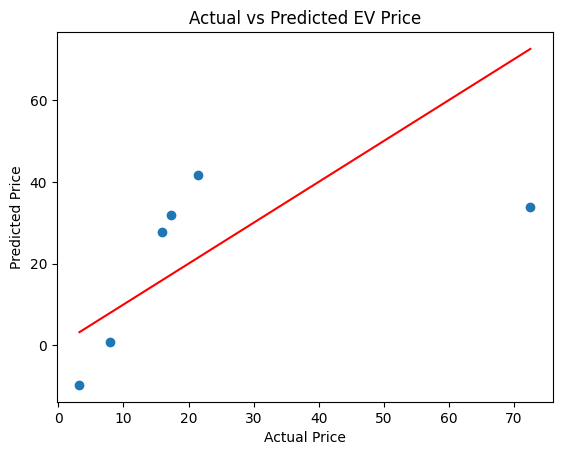

In [62]:
plt.scatter(y_test,y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted EV Price")
plt.show()


In [63]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R-squared:", r2)

Mean Absolute Error: 17.50805429306669
Mean Squared Error: 410.5501772136186
Root Mean Squared Error: 20.262037834670494
R-squared: 0.21789874655994523
